### Imports

In [1]:
import kagglehub

path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\raian\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [3]:
import librosa
import librosa.display
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

import os
base_path = f'{path}/Data/'
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')

/
genres_original/
    blues/
    classical/
    country/
    disco/
    hiphop/
    jazz/
    metal/
    pop/
    reggae/
    rock/
images_original/
    blues/
    classical/
    country/
    disco/
    hiphop/
    jazz/
    metal/
    pop/
    reggae/
    rock/


### Exploration

In [7]:
def get_sample_path(genre, index):
    return f'{base_path}/genres_original/{genre}/{genre}.{index:05}.wav'

y, sr = librosa.load(get_sample_path('rock', 0))
print('y:', y, '\n')
print('y shape:', np.shape(y), '\n')
print('Sample Rate (KHz):', sr, '\n')

print('Len of Audio:', np.shape(y)[0]/sr)

y: [-0.03344727 -0.05490112 -0.05435181 ... -0.08416748  0.02886963
  0.1296997 ] 

y shape: (661794,) 

Sample Rate (KHz): 22050 

Len of Audio: 30.013333333333332


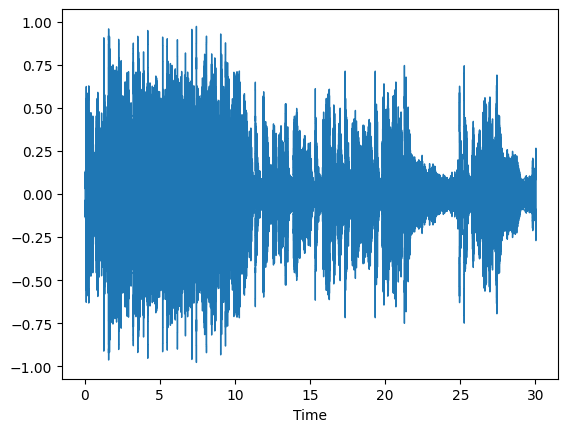

In [5]:
audio_file, _ = librosa.effects.trim(y)

# plt.figure(figsize = (16,16))
librosa.display.waveshow(y=audio_file, sr=sr)

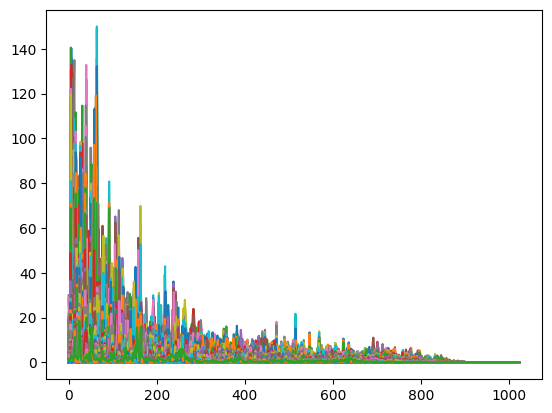

In [6]:
#Lets do fourier:
n_fft = 2048
hop_length = 512

D = np.abs(librosa.stft(audio_file, n_fft=n_fft, hop_length=hop_length))
plt.plot(D)
print("")

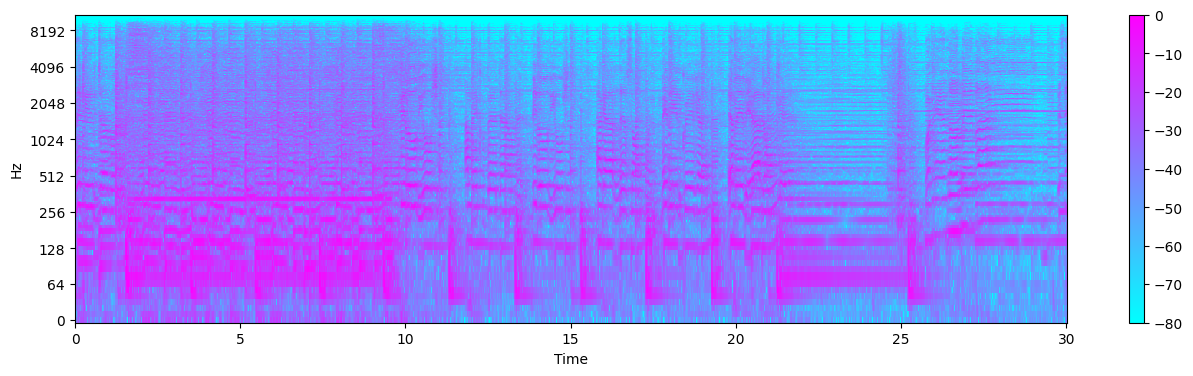

In [7]:
db = librosa.amplitude_to_db(D, ref=np.max)
plt.figure(figsize=(16, 4))
librosa.display.specshow(db, sr=sr, hop_length=hop_length, x_axis = 'time', y_axis = 'log', cmap = 'cool')
plt.colorbar()

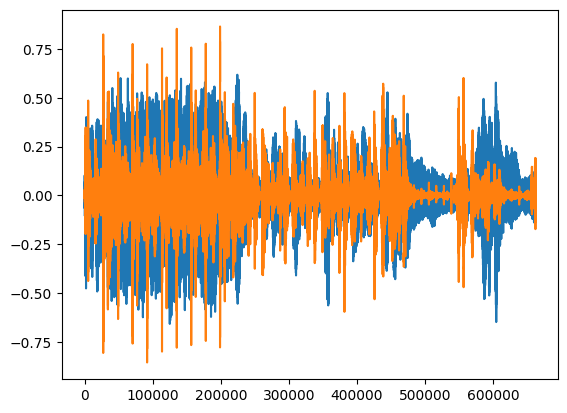

In [8]:
y_harm, y_perc = librosa.effects.hpss(audio_file)
plt.plot(y_harm)
plt.plot(y_perc)

In [9]:
tempo, _ = librosa.beat.beat_track(y=y, sr = sr)
tempo[0]

np.float64(123.046875)

In [13]:
data = pd.read_csv(base_path + 'features_30_sec.csv')
data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [14]:
data.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

<Axes: >

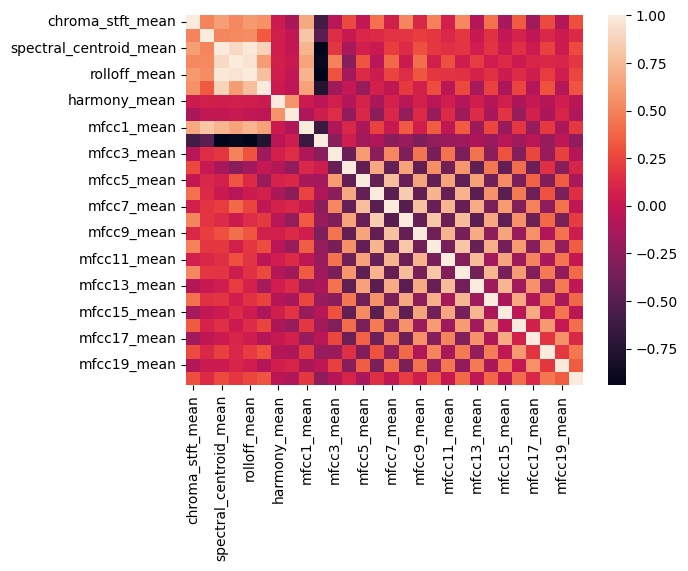

In [15]:
mean_cols = [col for col in data.columns if 'mean' in col]
var_cols = [col for col in data.columns if 'var' in col]

corr_matrix = data[mean_cols].corr()
sns.heatmap(corr_matrix)

<Axes: xlabel='label', ylabel='tempo'>

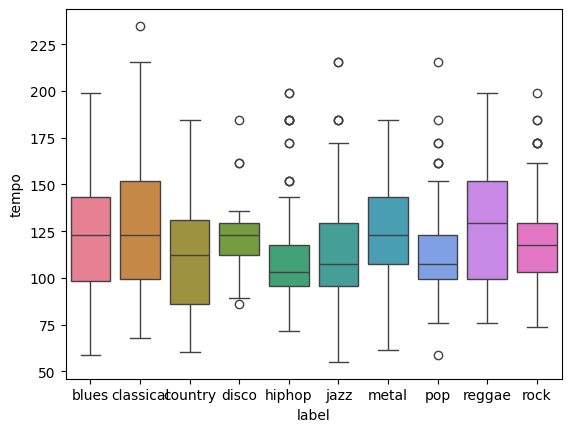

In [19]:
sns.boxplot(data, x='label', y='tempo', palette='husl')

[0.23568344 0.1665449 ]


<Axes: xlabel='PC1', ylabel='PC2'>

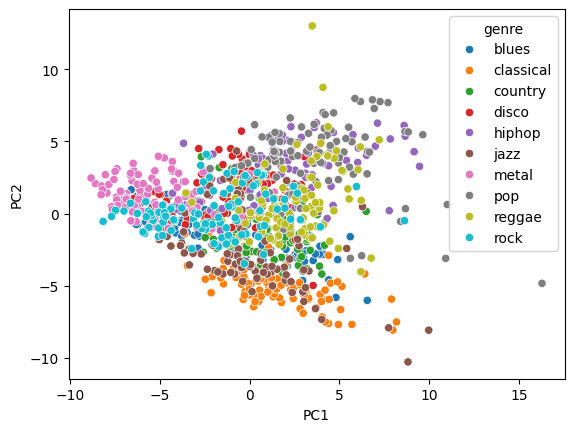

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

y = data['label']
x = data.drop(['label', 'filename'], axis=1)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
res = pca.fit_transform(x_scaled)
print(pca.explained_variance_ratio_)

pca_df = pd.DataFrame(data=res, columns=['PC1', 'PC2'])
pca_df['genre'] = y

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='genre')

### The fun part

In [57]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import SpectralClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from xgboost import plot_tree, plot_importance

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

In [58]:
x = data.drop(['label', 'filename'], axis=1)
y = data['label']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
len(x)

1000

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.1)
len(x_train), len(x_test)

(900, 100)

In [ ]:
def assess_model(model, name):
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    print(f"Accuracy of {name}: ", round(accuracy_score(y_test, preds), 2))

In [62]:
sgd = SGDClassifier(max_iter=5000, random_state=0)
assess_model(sgd, "Stochastic Gradient Descent")

knn = KNeighborsClassifier(n_neighbors=19)
assess_model(knn, "KNN")

rforest = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0)
assess_model(rforest, "Random Forest")

svm = SVC(decision_function_shape="ovo")
assess_model(svm, "Support Vector Machine")

lg = LogisticRegression(random_state=0, solver='lbfgs')
assess_model(lg, "Logistic Regression")

nn = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5000, 10), random_state=1)
assess_model(nn, "Neural Nets")

xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05)
assess_model(xgb, "Cross Gradient Booster")

Accuracy of SGDClassifier(max_iter=5000, random_state=0):  0.63
Accuracy of KNeighborsClassifier(n_neighbors=19):  0.62
Accuracy of RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=0):  0.76
Accuracy of SVC(decision_function_shape='ovo'):  0.67
Accuracy of LogisticRegression(random_state=0):  0.74
Accuracy of MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5000, 10), random_state=1,
              solver='lbfgs'):  0.71
Accuracy of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_d

<Axes: >

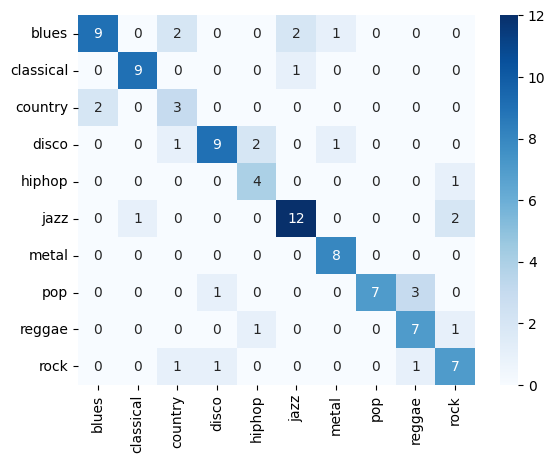

In [66]:
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05)
xgb.fit(x_train, y_train)
preds = xgb.predict(x_test)
conf_matrix = confusion_matrix(y_test, preds)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', xticklabels = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"],
           yticklabels=["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"])

### HuBERT

In [4]:
import torch
print(torch.__version__)

2.11.0+cu126


In [ ]:
import torch
import librosa
from transformers import Wav2Vec2FeatureExtractor, AutoModel

# processor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
# model = AutoModel.from_pretrained("facebook/hubert-base-ls960", dtype=torch.float16, attn_implementation="sdpa")

# audio, sr = librosa.load(get_sample_path('metal', 0), sr=16000, mono=True)
# audio = audio[:16000*10]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 3983.57it/s]


In [22]:
from torch.utils.data import Dataset, DataLoader
class MusicDataset(Dataset):
    def __init__(self, file_paths, labels, processor, max_len):
        super().__init__()
        self.file_paths = file_paths
        self.labels = labels
        self.processor = processor
        self.max_len = max_len

    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        path = self.file_paths[index]
        label = self.labels[index]

        audio, _ = librosa.load(path, sr=16000, mono=True)
        if len(audio) < self.max_len:
            np.pad(audio, self.max_len-len(audio))
        else:
            audio = audio[:self.max_len]

        inputs = self.processor(audio, 
                                sampling_rate=16000,
                                return_tensors="pt",
                                padding=False)
        
        return {
                'input_values': inputs.input_values.squeeze(0),
                'labels': torch.tensor(label)
            }

In [8]:
# import torch.nn as nn
# from transformers import Wav2Vec2FeatureExtractor, HubertModel

# class HuBERTForMusicClassification(nn.Module):
#     def __init__(self, n_labels):
#         super().__init__()
#         self.model = HubertModel.from_pretrained('facebook/hubert-base-ls960')

#         for param in self.model.parameters():
#             param.requires_grad = False
        
#         self.classifier = nn.Sequential(
#             nn.Linear(self.model.config.hidden_size, 256),
#             nn.ReLU(),
#             nn.Dropout(0.1),
#             nn.Linear(256, n_labels)
#         )

#     def forward(self, x):
#         embeds = self.model(x)
#         pooled = embeds.last_hidden_state.mean(dim=1)
#         logits = self.classifier(embeds)
#         return logits

In [23]:
import evaluate
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(logits, labels):
    preds = torch.argmax(logits)
    return accuracy_metric.compute(predictions=preds, references=labels)

In [29]:
import soundfile as sf

paths, labels = [], []
LABEL2ID = {}
ID2LABEL = {}
curr_dir = os.path.join(base_path, 'genres_original')

for i, dir in enumerate(os.listdir(curr_dir)):
    LABEL2ID[dir] = i
    ID2LABEL[i] = dir
    for sample in os.listdir(os.path.join(curr_dir, dir)):
        full_path = os.path.join(curr_dir, dir, sample)
        try:
            sf.SoundFile(full_path)  # quick validity check, no data loaded
            paths.append(full_path)
            labels.append(i)
        except Exception:
            print(f"Skipping corrupt file: {full_path}")

Skipping corrupt file: C:\Users\raian\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1/Data/genres_original\jazz\jazz.00054.wav


In [30]:
from transformers import HubertForSequenceClassification
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(paths, labels, test_size=0.1)
processor = Wav2Vec2FeatureExtractor.from_pretrained('facebook/hubert-base-ls960')

train_ds = MusicDataset(x_train, y_train, processor, 16000 * 10)
test_ds = MusicDataset(x_test, y_test, processor, 16000 * 10)

model = HubertForSequenceClassification.from_pretrained(
    'facebook/hubert-base-ls960',
    num_labels=len(ID2LABEL),
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    ignore_mismatched_sizes=True,
)

for param in model.parameters():
    param.requires_grad = False

for param in model.projector.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.1f}%)")

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 59070.76it/s]
HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.bias    | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 199,434 / 94,571,146 params (0.2%)


In [ ]:
from transformers import TrainingArguments, Trainer
args = TrainingArguments(
    output_dir='hubert',
    num_train_epochs=10,
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

def collate_fn(batch):
    input_values = [{"input_values": item["input_values"]} for item in batch]
    padded = processor.pad(input_values, padding=True, return_tensors="pt")
    padded["labels"] = torch.tensor(
        [item["labels"] for item in batch], dtype=torch.long
    )
    return padded

trainer = Trainer(model, args, train_dataset=train_ds, eval_dataset=test_ds, data_collator=collate_fn)
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,2.189185


KeyError: "The `metric_for_best_model` training argument is set to 'eval_accuracy', which is not found in the evaluation metrics. The available evaluation metrics are: ['eval_loss']. Consider changing the `metric_for_best_model` via the TrainingArguments."